# Benchmarks - Mixture initialisation and updating

**Main considerations when implementing HPs optimisation**
- we want a cost-effective initialisation
- we want a smart update using batched likelihoods

---
## Setup

In [1]:
from MagmaClustPy.mixture import update_mixture

# Jax configuration
USE_JIT = True
USE_X64 = True
DEBUG_NANS = False
VERBOSE = False

In [2]:
# Standard library imports
import os
os.environ['JAX_ENABLE_X64'] = str(USE_X64).lower()

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

from typing import Tuple, Any, Optional

In [3]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)

from jax import vmap, Array
import jax.numpy as jnp
import jax.random as jrd
from kernax import DiagKernel, ExpKernel, BatchKernel

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [4]:
# Local
from MagmaClustPy.utils import preprocess_db
from MagmaClustPy.hyperpost import hyperpost
from MagmaClustPy.custom_kernels import SEMagmaKernel

In [5]:
# Config
key = jrd.PRNGKey(0)
test_db_size = "small"
nb_cluster = 4

---
## Plot functions

In [6]:
def plot_mixture(inputs: Array, outputs: Array,
                 cluster_id: Optional[Array] = None,
                 post_grid: Optional[Array] = None, post_means: Optional[Array] = None, post_covs: Optional[Array] = None,
                 point_alpha=0.15, curve_alpha=1, ci_alpha=0.3,
                 title="mixture", fig=None, ax=None, key: Optional[Array] = jrd.PRNGKey(0)) -> Tuple[Any, Any]:
	"""
	Plot the data points of tasks, and the posterior mean and confidence intervals of clusters.

	:param inputs: x-coordinates of points. Shape (T, N)
	:param outputs: y-coordinates of points. Shape (T, N)
	:param cluster_id: ids of clusters. dtype int, shape (T,), starts at 0. If provided, points and curves are coloured accordingly. If not, random colours are used.
	:param post_grid: grid over which the posterior means and covariances are computed. Shape (G,)
	:param post_means: posterior mean distribution of the cluster GPs. Shape (K, G)
	:param post_covs: posterior covariance matrices of the cluster GPs. The diagonal is used to compute confidence intervals. Shape (K, G, G)
	:param point_alpha: transparency of the data points.
	:param curve_alpha: transparency of the posterior mean curves.
	:param ci_alpha: transparency of the confidence intervals.
	:param title: title of the plot.
	:param fig: matplotlib figure to use. If None, a new figure is created.
	:param ax: matplotlib axes to use. If None, new axes are created.
	:param key: JAX random key.
	:return: fig, ax
	"""
	# Check parameters consistency
	# post_grid, post_means, post_covs must be all provided or none
	if (post_grid is None) + (post_means is None) + (post_covs is None) not in (0, 3):
		raise ValueError("post_grid, post_means and post_covs must be all provided or none.")
	# fig, ax must be both provided or none
	if (fig is None) + (ax is None) not in (0, 2):
		raise ValueError("fig and ax must be both provided or none.")
	# if cluster_id and post_means are provided, no id should be higher than post_means and post_covs shape[0]
	if cluster_id is not None and post_means is not None:
		if int(jnp.max(cluster_id)) >= post_means.shape[0]:
			raise ValueError(f"cluster_id has max value {int(jnp.max(cluster_id))} but post_means has first dim {post_means.shape[0]}.")


	# Create figure and axes if not provided
	if fig is None or ax is None:
		fig, ax = plt.subplots(figsize=(8, 6))

	# Retrieve number of clusters
	if post_means is not None:
		nb_clusters = post_means.shape[0]
	elif cluster_id is not None:
		nb_clusters = int(jnp.max(cluster_id)) + 1
	else:
		nb_clusters = 5  # Default value

	# Choose colours
	point_cmap = plt.get_cmap('tab10')
	point_colors = [point_cmap(i % 10) for i in range(nb_clusters)]

	# If cluster_id not provided but post_means provided, use different cmap for curves
	if cluster_id is None and post_means is not None:
		curve_cmap = plt.get_cmap('Set2')
		curve_colors = [curve_cmap(i % 10) for i in range(nb_clusters)]
	else:
		curve_colors = point_colors

	# If cluster_id not provided, assign all points to random cluster in [0, nb_clusters)
	if cluster_id is None:
		key, subkey = jrd.split(key)
		cluster_id = jrd.randint(subkey, shape=(inputs.shape[0],), minval=0, maxval=nb_clusters)

	# Plot data points
	for x, y, c in zip(inputs, outputs, cluster_id):
		color = point_colors[int(c)]

		mask = ~jnp.isnan(y)
		ax.scatter(x[mask], y[mask], color=color, alpha=point_alpha, marker='.')

	# Plot posterior means and confidence intervals
	if post_means is not None:
		for k in range(nb_clusters):
			mean = post_means[k]
			std = jnp.sqrt(jnp.diag(post_covs[k]))
			color = curve_colors[k]

			ax.fill_between(post_grid, mean - 2*std, mean + 2*std,
							color=color, alpha=ci_alpha, label=f'95% CI Cluster {k+1}')
			ax.plot(post_grid, mean, color=color, alpha=curve_alpha, linewidth=2,
					label=f'Posterior Mean Cluster {k+1}')

	# Final plot adjustments
	ax.set_title(title)
	ax.set_xlabel("Input")
	ax.set_ylabel("Output")
	ax.grid()

	# Return figure and axes
	return fig, ax

---
## Current implementation

### Mixture initialisation

In [7]:
import MagmaClustPy
init_mixture_old = MagmaClustPy.initialisation.init_mixture

### Mixture update

In [8]:
update_mixture_old = MagmaClustPy.mixture.update_mixture

---
## Custom implementation(s)

*Start by copy-pasting the original function from the MagmaClustPy module, then bring modifications*

We want to ...

### Mixture initialisation

In [9]:
"""
This script will feature functions used to initialise elements of the MagmaClustPy model, including:
* initial hyperparameters of kernels
* the prior mean
* initial mixture of mean processes
* ...
"""
from functools import partial

import jax.numpy as jnp
from jax import jit

from MagmaClustPy.kmeans import k_means

# TODO: init_kernels

# TODO: init_prior_mean


#@partial(jit, static_argnums=(1, 2))
def init_mixture(padded_outputs, k, shared_hp=True):
	"""
	Compute the initial assignment of outputs between k clusters using k_means and a naive dimensionality reduction based on task statistics (min, mean, max)

	:param padded_outputs: the outputs from each task, (jnp.array, shape=(T, Max_N))
	:param k: the number of clusters (int)
	:param shared_hp: whether hyperparameters are shared between tasks (bool, default=True)
	:return: the initial mixture as a one-hot encoded array (jnp.array, shape=(k, T))
	"""
	outputs = padded_outputs.squeeze().T

	# Compute statistics
	features = jnp.stack([
		jnp.nanmin(outputs, axis=0),  # Min
		jnp.nanmean(outputs, axis=0),  # Mean
		jnp.nanmax(outputs, axis=0)  # Max
	], axis=-1).squeeze()

	if not shared_hp:
		features = jnp.concatenate([
			features,
			jnp.nanvar(outputs, axis=0, ddof=1).reshape(-1, 1)  # Variance
		], axis=-1)

	# Run k-means
	_, labels, _= k_means(features, n_clusters=k, n_init=10, max_iter=100)

	# One-hot encode labels
	labels = jnp.eye(k)[labels]

	return labels.T


### Mixture update

In [10]:
from typing import Optional

from jax import Array
from kernax import AbstractKernel

from MagmaClustPy.likelihoods import compute_task_nlls, magma_nll


@partial(jit, static_argnums=(6, 7))
def update_mixture(task_kernel: AbstractKernel, inputs: Array, outputs: Array,
					 mappings: Array, post_means: Array, post_covs: Array,
	                 shared_hp: bool, cluster_hp: bool,
					 jitter: Array = jnp.array(1e-5)):
	task_nlls = -compute_task_nlls(task_kernel, inputs, outputs, mappings, post_means, post_covs, shared_hp, cluster_hp, jitter)

	# Make probabilities sum to 1 across tasks, by applying softmax
	new_mixture = jnp.exp(task_nlls - jnp.max(task_nlls, axis=0, keepdims=True))
	new_mixture /= jnp.sum(new_mixture, axis=0, keepdims=True)

	return new_mixture

In [11]:
init_mixture_new = init_mixture
update_mixture_new = update_mixture

---
## Comparison

In [12]:
jitter = jnp.array(1e-5)

### MagmaClust scenarios

We batch the hyperpost function so that it returns `post_mean` of shape `(K, N)` and `post_cov` of shape `(K, N, N)`

Depending on the scenario, we have to batch task kernels differently.

`fully shared HP` = `shared_hp` & `! cluster_hp`

`shared HP in cluster` = `shared_hp` & `cluster_hp`

`fully distinct HP` = `! shared_hp` & `! cluster_hp`

`distinct HP in cluster` = `! shared_hp` & `cluster_hp`

In this section, we only use **distinct inputs datasets.**

#### Shared HP + no Cluster HP

- Each task has 1 set of HPs, optimised on the whole dataset
- They are optimised to maximise the likelihood of _**all**_ tasks, with respect to **_all_** clusters.

##### Setup

In [13]:
db = pd.read_csv(f"../datasets/K={nb_cluster}/{test_db_size}_distinct_input_shared_hp.csv")
padded_inputs, padded_outputs, mappings, all_inputs = preprocess_db(db)
prior_mean = jnp.array(0.)
prior_mean_on_grid = jnp.full(all_inputs.squeeze().shape, 0)
all_inputs.shape, padded_inputs.shape

((41, 1), (20, 20, 1))

In [14]:
mean_kern = SEMagmaKernel(length_scale=.2, variance=5.)
task_kern = SEMagmaKernel(length_scale=.2, variance=1.) + DiagKernel(ExpKernel(2.5))
task_kern = BatchKernel(task_kern, batch_size=padded_inputs.shape[0], batch_in_axes=None, batch_over_inputs=True)  # Batch along tasks

In [15]:
shared_input = len(padded_inputs[0]) == len(all_inputs) and not jnp.any(jnp.isnan(padded_inputs))
shared_hp = jax.tree.all(jax.tree.map(lambda x: x is None, task_kern.batch_in_axes))
cluster_hp = False

shared_input, shared_hp, cluster_hp

(False, True, False)

##### Mixture initialisation

In [16]:
init_mix_old = init_mixture_old(padded_outputs, k=nb_cluster, shared_hp=shared_hp)
init_mix_old.shape

(4, 20)

In [17]:
init_mix_new = init_mixture_new(padded_outputs, k=nb_cluster, shared_hp=shared_hp)
init_mix_new.shape

(4, 20)

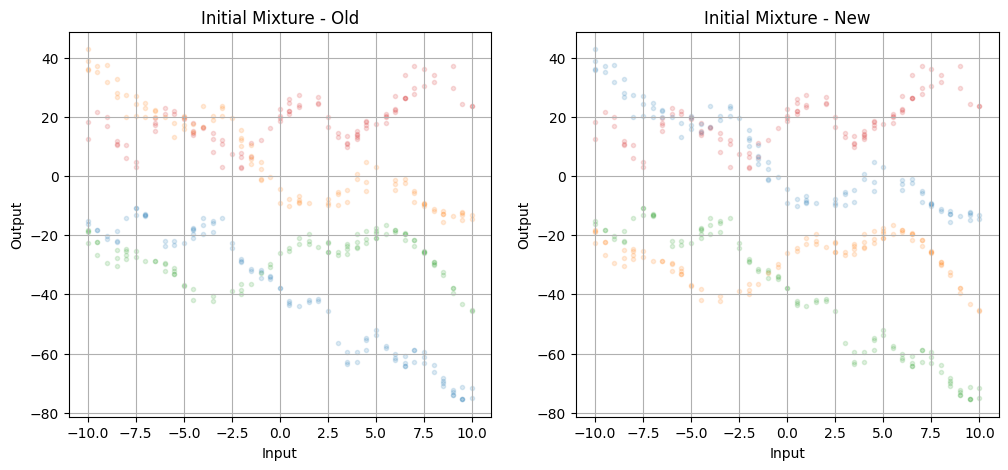

In [18]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(init_mix_old, axis=0),
	title="Initial Mixture - Old",
	fig=fig, ax=axes[0])
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(init_mix_new, axis=0),
	title="Initial Mixture - New",
	fig=fig, ax=axes[1])
plt.show()

In [19]:
%%timeit -n 3 -r 2

init_mixture_old(padded_outputs, k=nb_cluster, shared_hp=shared_hp).block_until_ready()

2.35 ms ± 245 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


In [20]:
%%timeit -n 3 -r 2

init_mixture_new(padded_outputs, k=nb_cluster, shared_hp=shared_hp).block_until_ready()

2.22 ms ± 153 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


##### Hyperpost

In [21]:
batched_hyperpost = vmap(hyperpost, in_axes=(None, None, None, None, None, None, None, None, None, 0))

In [22]:
post_means_old, post_covs_old = batched_hyperpost(
	padded_inputs, padded_outputs, mappings, all_inputs,
	prior_mean, mean_kern, task_kern,
	shared_input, shared_hp, init_mix_old)
post_means_old.shape, post_covs_old.shape

((4, 41), (4, 41, 41))

In [23]:
post_means_new, post_covs_new = batched_hyperpost(
	padded_inputs, padded_outputs, mappings, all_inputs,
	prior_mean, mean_kern, task_kern,
	shared_input, shared_hp, init_mix_new)
post_means_new.shape, post_covs_new.shape

((4, 41), (4, 41, 41))

##### Mixture update

In [24]:
updated_mix_old = update_mixture_old(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_old, post_covs_old,
	shared_hp, cluster_hp, jitter)

In [25]:
updated_mix_new = update_mixture_new(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_new, post_covs_new,
	shared_hp, cluster_hp, jitter)

In [26]:
np.asarray(jnp.argmax(updated_mix_new, axis=0))

array([2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0],
      dtype=int32)

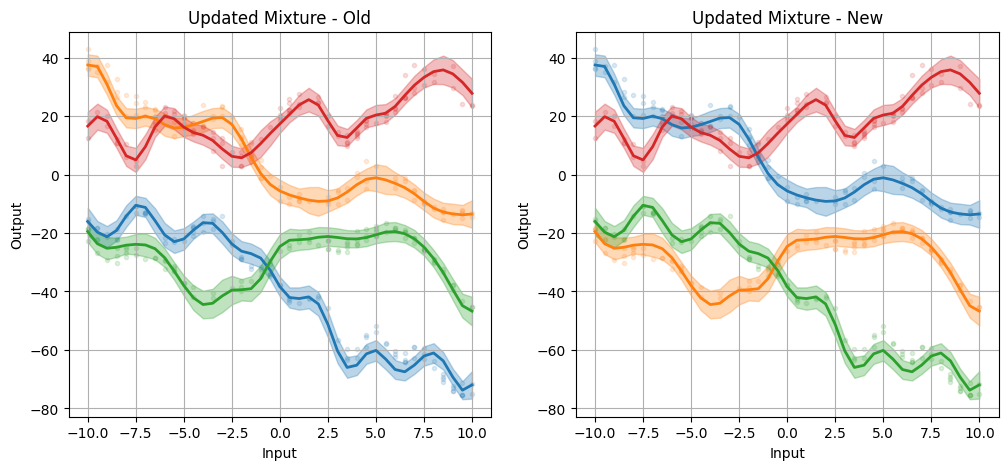

In [27]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(updated_mix_old, axis=0),
	post_grid=all_inputs.squeeze(), post_means=post_means_old, post_covs=post_covs_old,
	title="Updated Mixture - Old",
	fig=fig, ax=axes[0])
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(updated_mix_new, axis=0),
	post_grid=all_inputs.squeeze(), post_means=post_means_new, post_covs=post_covs_new,
	title="Updated Mixture - New",
	fig=fig, ax=axes[1])
plt.show()

In [28]:
%%timeit -n 3 -r 2

updated_mix_old = update_mixture_old(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_old, post_covs_old,
	shared_hp, cluster_hp, jitter).block_until_ready()

4.59 ms ± 742 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


In [29]:
%%timeit -n 3 -r 2

update_mixture_new(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_new, post_covs_new,
	shared_hp, cluster_hp, jitter).block_until_ready()

The slowest run took 24.47 times longer than the fastest. This could mean that an intermediate result is being cached.
8.76 ms ± 8.08 ms per loop (mean ± std. dev. of 2 runs, 3 loops each)


#### Shared HP + Cluster HP

* Each task has K sets of HPs
* These K sets of HPs are shared among all tasks
* They are optimised to maximise the likelihood of **_all_** tasks (weighted by mixture coefficients), with respect to **_each_** cluster

##### Setup

In [30]:
db = pd.read_csv(f"../datasets/K={nb_cluster}/{test_db_size}_distinct_input_shared_hp.csv")
padded_inputs, padded_outputs, mappings, all_inputs = preprocess_db(db)
prior_mean = jnp.array(0.)
prior_mean_on_grid = jnp.full(all_inputs.squeeze().shape, 0)
all_inputs.shape, padded_inputs.shape

((41, 1), (20, 20, 1))

In [31]:
mean_kern = SEMagmaKernel(length_scale=.2, variance=5.)
task_kern = SEMagmaKernel(length_scale=.2, variance=1.) + DiagKernel(ExpKernel(2.5))
task_kern = BatchKernel(task_kern, batch_size=padded_inputs.shape[0], batch_in_axes=None, batch_over_inputs=True)  # Batch along tasks
task_kern = BatchKernel(task_kern, batch_size=nb_cluster, batch_in_axes=0, batch_over_inputs=False)  # Batch along clusters

In [32]:
shared_input = len(padded_inputs[0]) == len(all_inputs) and not jnp.any(jnp.isnan(padded_inputs))
shared_hp = jax.tree.all(jax.tree.map(lambda x: x is None, task_kern.inner_kernel.batch_in_axes))
cluster_hp = jax.tree.all(jax.tree.map(lambda x: x is None, task_kern.batch_in_axes))  # FIXME
cluster_hp = True

shared_input, shared_hp, cluster_hp

(False, True, True)

##### Mixture initialisation

In [33]:
init_mix_old = init_mixture_old(padded_outputs, k=nb_cluster, shared_hp=shared_hp)
init_mix_old.shape

(4, 20)

In [34]:
init_mix_new = init_mixture_new(padded_outputs, k=nb_cluster, shared_hp=shared_hp)
init_mix_new.shape

(4, 20)

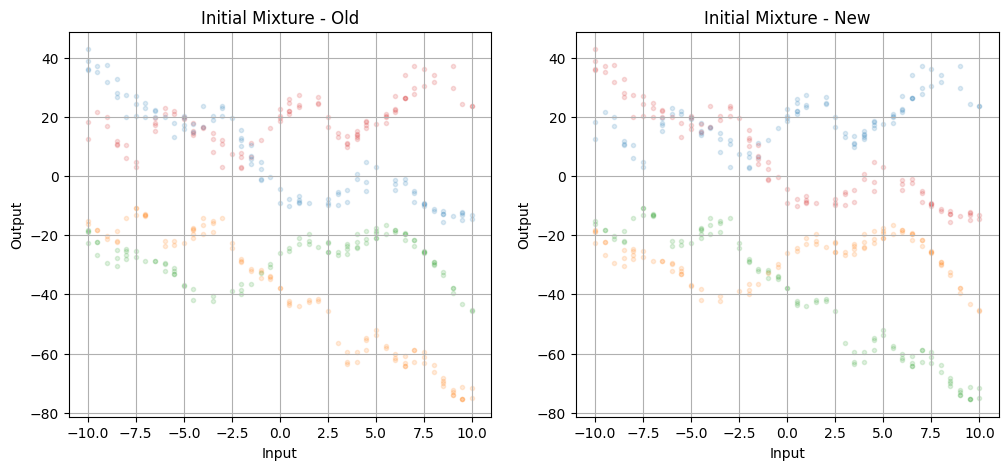

In [35]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(init_mix_old, axis=0),
	title="Initial Mixture - Old",
	fig=fig, ax=axes[0])
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(init_mix_new, axis=0),
	title="Initial Mixture - New",
	fig=fig, ax=axes[1])
plt.show()

In [36]:
%%timeit -n 3 -r 2

init_mixture_old(padded_outputs, k=nb_cluster, shared_hp=shared_hp).block_until_ready()

2.22 ms ± 138 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


In [37]:
%%timeit -n 3 -r 2

init_mixture_new(padded_outputs, k=nb_cluster, shared_hp=shared_hp).block_until_ready()

2.06 ms ± 237 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


##### Hyperpost

In [38]:
batched_hyperpost = vmap(hyperpost, in_axes=(None, None, None, None, None, None, task_kern.batch_in_axes, None, None, 0))

In [39]:
post_means_old, post_covs_old = batched_hyperpost(
	padded_inputs, padded_outputs, mappings, all_inputs,
	prior_mean, mean_kern, task_kern.inner_kernel,
	shared_input, shared_hp, init_mix_old)
post_means_old.shape, post_covs_old.shape

((4, 41), (4, 41, 41))

In [40]:
post_means_new, post_covs_new = batched_hyperpost(
	padded_inputs, padded_outputs, mappings, all_inputs,
	prior_mean, mean_kern, task_kern.inner_kernel,
	shared_input, shared_hp, init_mix_new)
post_means_new.shape, post_covs_new.shape

((4, 41), (4, 41, 41))

##### Mixture update

In [41]:
updated_mix_old = update_mixture_old(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_old, post_covs_old,
	shared_hp, cluster_hp, jitter)

In [42]:
updated_mix_new = update_mixture_new(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_new, post_covs_new,
	shared_hp, cluster_hp, jitter)

In [43]:
np.asarray(jnp.argmax(updated_mix_new, axis=0))

array([2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 3, 3, 3, 3, 3],
      dtype=int32)

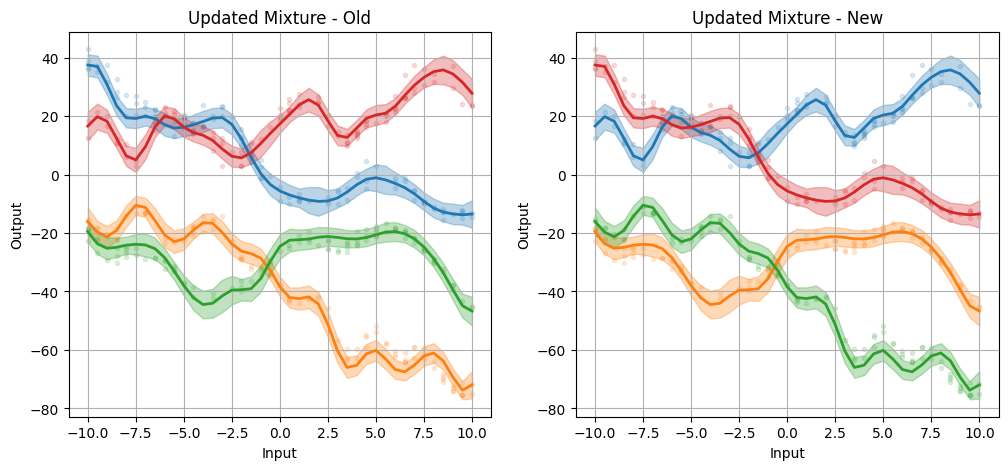

In [44]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(updated_mix_old, axis=0),
	post_grid=all_inputs.squeeze(), post_means=post_means_old, post_covs=post_covs_old,
	title="Updated Mixture - Old",
	fig=fig, ax=axes[0])
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(updated_mix_new, axis=0),
	post_grid=all_inputs.squeeze(), post_means=post_means_new, post_covs=post_covs_new,
	title="Updated Mixture - New",
	fig=fig, ax=axes[1])
plt.show()

In [45]:
%%timeit -n 3 -r 2

updated_mix_old = update_mixture_old(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_old, post_covs_old,
	shared_hp, cluster_hp, jitter).block_until_ready()

562 μs ± 9.32 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


In [46]:
%%timeit -n 3 -r 2

update_mixture_new(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_new, post_covs_new,
	shared_hp, cluster_hp, jitter).block_until_ready()

561 μs ± 4.87 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


#### Distinct HP + no Cluster HP

* Each task has 1 set of HPs
* They are optimised to maximise the likelihood of _**each**_ task with respect to _**all**_ clusters (weighted by mixture coefficients)

##### Setup

In [47]:
db = pd.read_csv(f"../datasets/K={nb_cluster}/{test_db_size}_distinct_input_distinct_hp.csv")
padded_inputs, padded_outputs, mappings, all_inputs = preprocess_db(db)
prior_mean = jnp.array(0.)
prior_mean_on_grid = jnp.full(all_inputs.squeeze().shape, 0)
all_inputs.shape, padded_inputs.shape

((41, 1), (20, 20, 1))

In [48]:
mean_kern = SEMagmaKernel(length_scale=.2, variance=5.)
task_kern = SEMagmaKernel(length_scale=.2, variance=1.) + DiagKernel(ExpKernel(2.5))
task_kern = BatchKernel(task_kern, batch_size=padded_inputs.shape[0], batch_in_axes=0, batch_over_inputs=True)  # Batch along tasks

In [49]:
shared_input = len(padded_inputs[0]) == len(all_inputs) and not jnp.any(jnp.isnan(padded_inputs))
shared_hp = jax.tree.all(jax.tree.map(lambda x: x is None, task_kern.batch_in_axes))
cluster_hp = False

shared_input, shared_hp, cluster_hp

(False, False, False)

##### Mixture initialisation

In [50]:
init_mix_old = init_mixture_old(padded_outputs, k=nb_cluster, shared_hp=shared_hp)
init_mix_old.shape

(4, 20)

In [51]:
init_mix_new = init_mixture_new(padded_outputs, k=nb_cluster, shared_hp=shared_hp)
init_mix_new.shape

(4, 20)

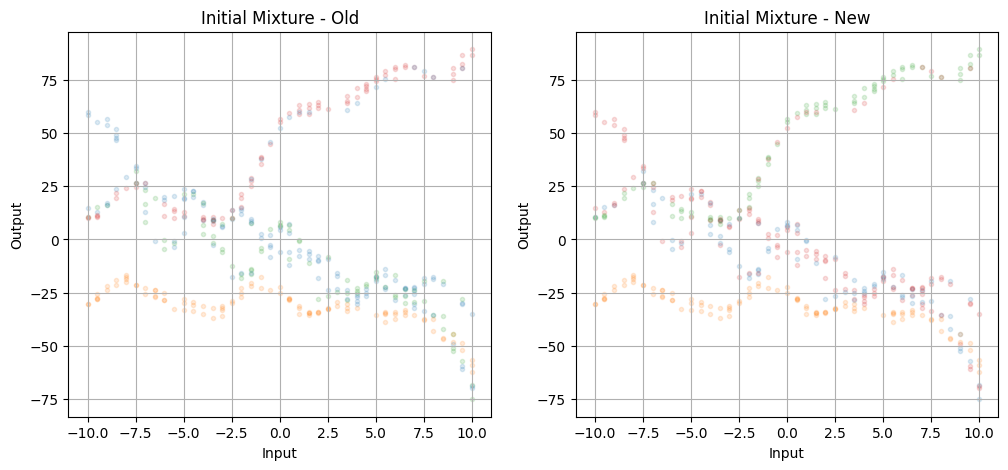

In [52]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(init_mix_old, axis=0),
	title="Initial Mixture - Old",
	fig=fig, ax=axes[0])
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(init_mix_new, axis=0),
	title="Initial Mixture - New",
	fig=fig, ax=axes[1])
plt.show()

In [53]:
%%timeit -n 3 -r 2

init_mixture_old(padded_outputs, k=nb_cluster, shared_hp=shared_hp).block_until_ready()

3.13 ms ± 325 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


In [54]:
%%timeit -n 3 -r 2

init_mixture_new(padded_outputs, k=nb_cluster, shared_hp=shared_hp).block_until_ready()

2.72 ms ± 227 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


##### Hyperpost

In [55]:
batched_hyperpost = vmap(hyperpost, in_axes=(None, None, None, None, None, None, None, None, None, 0))

In [56]:
post_means_old, post_covs_old = batched_hyperpost(
	padded_inputs, padded_outputs, mappings, all_inputs,
	prior_mean, mean_kern, task_kern,
	shared_input, shared_hp, init_mix_old)
post_means_old.shape, post_covs_old.shape

((4, 41), (4, 41, 41))

In [57]:
post_means_new, post_covs_new = batched_hyperpost(
	padded_inputs, padded_outputs, mappings, all_inputs,
	prior_mean, mean_kern, task_kern,
	shared_input, shared_hp, init_mix_new)
post_means_new.shape, post_covs_new.shape

((4, 41), (4, 41, 41))

##### Mixture update

In [58]:
updated_mix_old = update_mixture_old(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_old, post_covs_old,
	shared_hp, cluster_hp, jitter)

In [59]:
updated_mix_new = update_mixture_new(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_new, post_covs_new,
	shared_hp, cluster_hp, jitter)

In [60]:
np.asarray(jnp.argmax(updated_mix_new, axis=0))

array([3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1],
      dtype=int32)

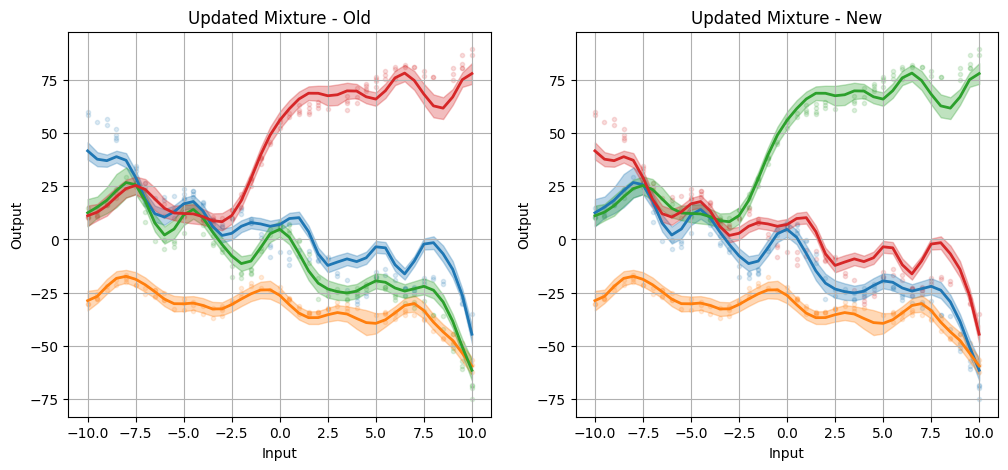

In [61]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(updated_mix_old, axis=0),
	post_grid=all_inputs.squeeze(), post_means=post_means_old, post_covs=post_covs_old,
	title="Updated Mixture - Old",
	fig=fig, ax=axes[0])
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(updated_mix_new, axis=0),
	post_grid=all_inputs.squeeze(), post_means=post_means_new, post_covs=post_covs_new,
	title="Updated Mixture - New",
	fig=fig, ax=axes[1])
plt.show()

In [62]:
%%timeit -n 3 -r 2

updated_mix_old = update_mixture_old(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_old, post_covs_old,
	shared_hp, cluster_hp, jitter).block_until_ready()

3.63 ms ± 143 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


In [63]:
%%timeit -n 3 -r 2

update_mixture_new(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_new, post_covs_new,
	shared_hp, cluster_hp, jitter).block_until_ready()

26.8 ms ± 729 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


#### Distinct HP + Cluster HP

- Each task has K sets of HPs
- Each set is specific to the task
- They are optimised to maximise the likelihood of _**each**_ task with respect to _**each**_ cluster

##### Setup

In [64]:
db = pd.read_csv(f"../datasets/K={nb_cluster}/{test_db_size}_distinct_input_distinct_hp.csv")
padded_inputs, padded_outputs, mappings, all_inputs = preprocess_db(db)
prior_mean = jnp.array(0.)
prior_mean_on_grid = jnp.full(all_inputs.squeeze().shape, 0)
all_inputs.shape, padded_inputs.shape

((41, 1), (20, 20, 1))

In [65]:
mean_kern = SEMagmaKernel(length_scale=.2, variance=5.)
task_kern = SEMagmaKernel(length_scale=.2, variance=1.) + DiagKernel(ExpKernel(2.5))
task_kern = BatchKernel(task_kern, batch_size=padded_inputs.shape[0], batch_in_axes=0, batch_over_inputs=True)  # Batch along tasks
task_kern = BatchKernel(task_kern, batch_size=nb_cluster, batch_in_axes=0, batch_over_inputs=False)  # Batch along clusters

In [66]:
shared_input = len(padded_inputs[0]) == len(all_inputs) and not jnp.any(jnp.isnan(padded_inputs))
shared_hp = jax.tree.all(jax.tree.map(lambda x: x is None, task_kern.inner_kernel.batch_in_axes))
cluster_hp = jax.tree.all(jax.tree.map(lambda x: x is None, task_kern.batch_in_axes))  # FIXME
cluster_hp = True

shared_input, shared_hp, cluster_hp

(False, False, True)

##### Mixture initialisation

In [67]:
init_mix_old = init_mixture_old(padded_outputs, k=nb_cluster, shared_hp=shared_hp)
init_mix_old.shape

(4, 20)

In [68]:
init_mix_new = init_mixture_new(padded_outputs, k=nb_cluster, shared_hp=shared_hp)
init_mix_new.shape

(4, 20)

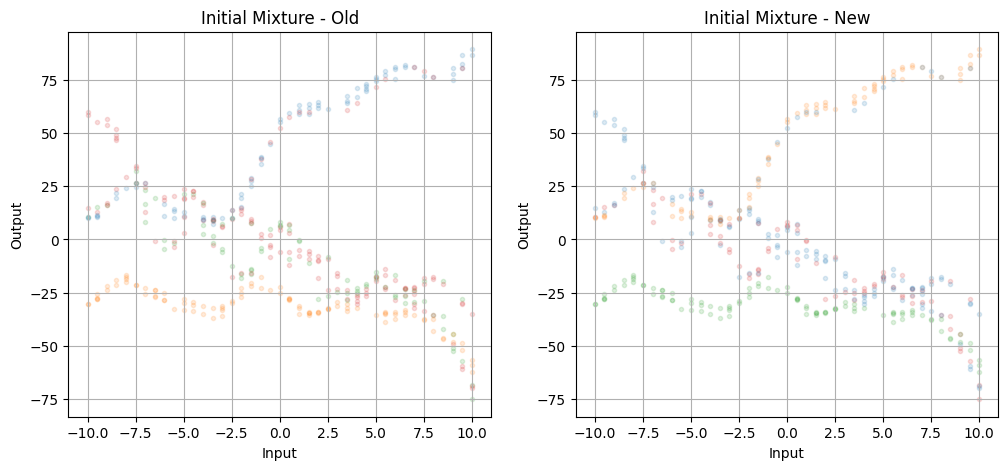

In [69]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(init_mix_old, axis=0),
	title="Initial Mixture - Old",
	fig=fig, ax=axes[0])
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(init_mix_new, axis=0),
	title="Initial Mixture - New",
	fig=fig, ax=axes[1])
plt.show()

In [70]:
%%timeit -n 3 -r 2

init_mixture_old(padded_outputs, k=nb_cluster, shared_hp=shared_hp).block_until_ready()

2.79 ms ± 459 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


In [71]:
%%timeit -n 3 -r 2

init_mixture_new(padded_outputs, k=nb_cluster, shared_hp=shared_hp).block_until_ready()

2.48 ms ± 159 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


##### Hyperpost

In [72]:
batched_hyperpost = vmap(hyperpost, in_axes=(None, None, None, None, None, None, task_kern.batch_in_axes, None, None, 0))

In [73]:
post_means_old, post_covs_old = batched_hyperpost(
	padded_inputs, padded_outputs, mappings, all_inputs,
	prior_mean, mean_kern, task_kern.inner_kernel,
	shared_input, shared_hp, init_mix_old)
post_means_old.shape, post_covs_old.shape

((4, 41), (4, 41, 41))

In [74]:
post_means_new, post_covs_new = batched_hyperpost(
	padded_inputs, padded_outputs, mappings, all_inputs,
	prior_mean, mean_kern, task_kern.inner_kernel,
	shared_input, shared_hp, init_mix_new)
post_means_new.shape, post_covs_new.shape

((4, 41), (4, 41, 41))

##### Mixture update

In [75]:
updated_mix_old = update_mixture_old(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_old, post_covs_old,
	shared_hp, cluster_hp, jitter)

In [76]:
updated_mix_new = update_mixture_new(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_new, post_covs_new,
	shared_hp, cluster_hp, jitter)

In [77]:
np.asarray(jnp.argmax(updated_mix_new, axis=0))

array([0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2],
      dtype=int32)

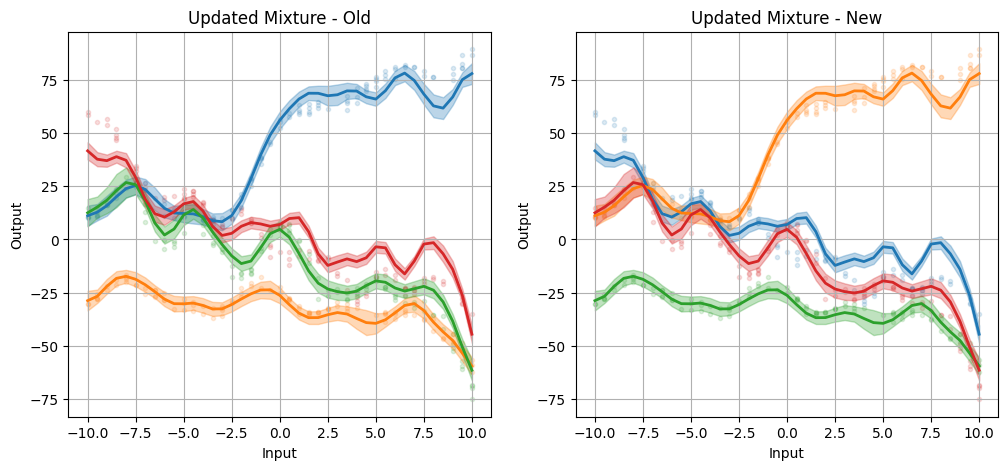

In [78]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(updated_mix_old, axis=0),
	post_grid=all_inputs.squeeze(), post_means=post_means_old, post_covs=post_covs_old,
	title="Updated Mixture - Old",
	fig=fig, ax=axes[0])
plot_mixture(
	padded_inputs, padded_outputs,
	cluster_id=jnp.argmax(updated_mix_new, axis=0),
	post_grid=all_inputs.squeeze(), post_means=post_means_new, post_covs=post_covs_new,
	title="Updated Mixture - New",
	fig=fig, ax=axes[1])
plt.show()

In [79]:
%%timeit -n 3 -r 2

updated_mix_old = update_mixture_old(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_old, post_covs_old,
	shared_hp, cluster_hp, jitter).block_until_ready()

541 μs ± 16.9 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


In [80]:
%%timeit -n 3 -r 2

update_mixture_new(
	task_kern, padded_inputs, padded_outputs,
	mappings, post_means_new, post_covs_new,
	shared_hp, cluster_hp, jitter).block_until_ready()

530 μs ± 35.5 μs per loop (mean ± std. dev. of 2 runs, 3 loops each)


## Conclusion

---